In [ ]:
!pip install -q timm seaborn

In [ ]:
import os
import zipfile
import random
import warnings

import numpy as np
import pandas as pd

from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    auc
)

from sklearn.calibration import calibration_curve

from sklearn.linear_model import LogisticRegression

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import (
    Dataset,
    DataLoader
)

import torchvision.transforms as transforms

import timm

import joblib

In [ ]:
os.makedirs("models", exist_ok=True)
os.makedirs("performance", exist_ok=True)

In [ ]:
IMAGE_SIZE = 224
BATCH_SIZE = 8
SEED = 42
N_SPLITS = 5

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

CLASS_NAMES = ["No_DR", "DR"]

MODEL_NAMES = [
    "efficientnet_b3",
    "convnext_tiny",
    "swin_tiny_patch4_window7_224"
]

In [ ]:
def set_seed(seed=42):

    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    torch.use_deterministic_algorithms(True)

    print(f"Seed set to {seed}")

In [ ]:
set_seed(SEED)

g = torch.Generator()
g.manual_seed(SEED)

Seed set to 42


In [ ]:
zip_path = "/content/DRdataset.zip"

extract_path = "/content/data"

if zipfile.is_zipfile(zip_path):

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:

        zip_ref.extractall(extract_path)


In [ ]:
data = []

for label_name in ["DR", "No_DR"]:

    folder = os.path.join(
        extract_path,
        label_name
    )

    for file in os.listdir(folder):

        data.append({

            "path": os.path.join(folder, file),

            "label": 1 if label_name=="DR" else 0
        })

df = pd.DataFrame(data)

df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)


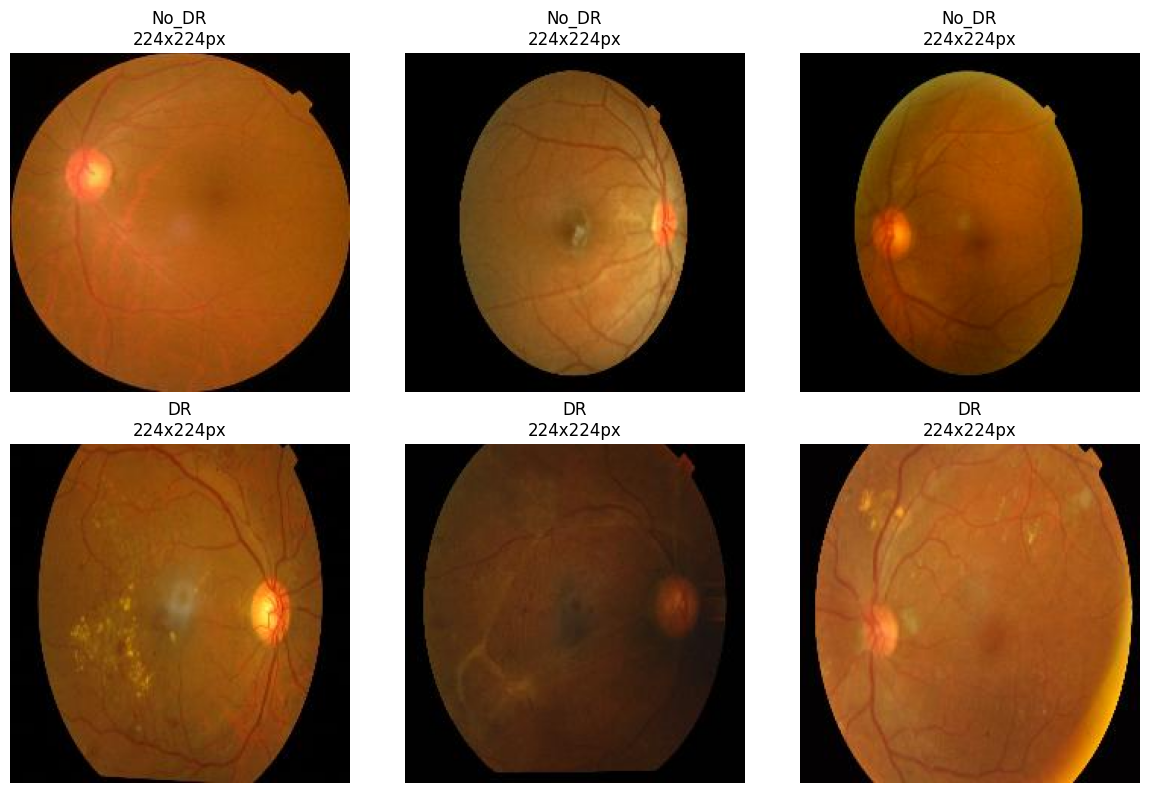

In [ ]:
def visualize_images(df):

    plt.figure(figsize=(12,8))

    # Ambil masing-masing 3 data per kelas
    dr_samples = df[df["label"] == 1].sample(
        n=3,
        random_state=42
    )

    no_dr_samples = df[df["label"] == 0].sample(
        n=3,
        random_state=42
    )

    # Gabungkan data
    sample_df = pd.concat(
        [no_dr_samples, dr_samples]
    ).reset_index(drop=True)

    for i in range(len(sample_df)):

        # Load image
        img = Image.open(
            sample_df.loc[i, "path"]
        ).convert("RGB")

        # Plot image
        plt.subplot(2, 3, i + 1)

        plt.imshow(img)

        plt.axis("off")

        # Label kelas
        label = (
            "DR"
            if sample_df.loc[i, "label"] == 1
            else "No_DR"
        )

        # Ukuran gambar
        width, height = img.size

        plt.title(
            f"{label}\n{width}x{height}px"
        )

    plt.tight_layout()

    plt.show()


# Visualisasi 3 citra per kelas
visualize_images(df)

In [ ]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=SEED
)

print("Train:", len(train_df))
print("Test :", len(test_df))


Train: 2270
Test : 568


In [ ]:
def create_loader(df, transform, shuffle=False):

    dataset = RetinaDataset(df, transform)

    loader_args = {
        "dataset": dataset,
        "batch_size": BATCH_SIZE,
        "shuffle": shuffle,
        "num_workers": 0
    }

    if shuffle:
        loader_args["generator"] = g

    return DataLoader(**loader_args)

In [ ]:
def crop_retina(img):

    img = np.array(img)

    gray = np.mean(img, axis=2)

    mask = gray > 20

    if mask.sum() == 0:

        return Image.fromarray(img)

    coords = np.argwhere(mask)

    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0)

    img = img[y0:y1, x0:x1]

    return Image.fromarray(img)


In [ ]:
def get_transforms(train=True):
    transform_list = [
        transforms.Lambda(crop_retina),
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    ]

    if train:
        transform_list.extend([
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
        ])

    transform_list.extend([
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ])

    return transforms.Compose(transform_list)


train_tf = get_transforms(train=True)
val_tf = get_transforms(train=False)

In [ ]:
class RetinaDataset(Dataset):

    def __init__(self, df, transform=None):

        self.df = df
        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        img = Image.open(
            row["path"]
        ).convert("RGB")

        label = row["label"]

        if self.transform:

            img = self.transform(img)

        return img, torch.tensor(
            label,
            dtype=torch.float32
        )


In [ ]:
MAX_EPOCHS = 30
PATIENCE = 5
BACKBONE_LR = 1e-5
HEAD_LR = 1e-3
POWER_K = 2

In [ ]:
class Model(nn.Module):

    def __init__(self, name):

        super().__init__()

        self.model = timm.create_model(
            name,
            pretrained=True
        )

        in_features = self.model.get_classifier().in_features

        self.model.reset_classifier(0)

        self.head = nn.Sequential(

            nn.Linear(in_features, 512),

            nn.BatchNorm1d(512),

            nn.SiLU(),

            nn.Dropout(0.4),

            nn.Linear(512, 128),

            nn.BatchNorm1d(128),

            nn.SiLU(),

            nn.Dropout(0.3),

            nn.Linear(128, 1)
        )

    def forward(self, x):

        x = self.model(x)

        x = self.head(x)

        return x


In [ ]:
def compute_metrics(y_true, y_pred):

    y_bin = (y_pred > 0.5).astype(int)

    cm = confusion_matrix(
        y_true,
        y_bin
    )

    cm_percent = (
        cm.astype(float)
        / cm.sum(axis=1, keepdims=True)
    ) * 100

    return {

        "accuracy": accuracy_score(
            y_true,
            y_bin
        ),

        "precision": precision_score(
            y_true,
            y_bin,
            zero_division=0
        ),

        "recall": recall_score(
            y_true,
            y_bin,
            zero_division=0
        ),

        "f1": f1_score(
            y_true,
            y_bin,
            zero_division=0
        ),

        "auc": roc_auc_score(
            y_true,
            y_pred
        ),

        "cm": cm,

        "cm_percent": cm_percent
    }


In [ ]:
def plot_cm(
    cm,
    title,
    fmt=".2f",
    save_path=None
):

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt=fmt,
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )

    plt.xlabel("Predicted")
    plt.ylabel("True")

    plt.title(title)

    if save_path is not None:

        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()
    plt.close()

In [ ]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    running_loss = 0

    preds_all = []
    labels_all = []
    probs_all = []

    with torch.set_grad_enabled(is_train):

        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(imgs).squeeze()

            loss = criterion(outputs, labels.float())

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            probs = torch.sigmoid(outputs)

            running_loss += loss.item()

            probs_all.extend(probs.detach().cpu().numpy())
            preds_all.extend((probs > 0.5).cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    metrics = compute_metrics(
        np.array(labels_all),
        np.array(probs_all)
    )

    return running_loss / len(loader), metrics

In [ ]:
MODEL_NAMES = [

    "efficientnet_b3",

    "convnext_tiny",

    "swin_tiny_patch4_window7_224"
]

In [ ]:
  all_models = []
  all_weights = []

  history_all = {}

  for model_name in MODEL_NAMES:

      print(f"\n========== {model_name} ==========")

      models = []
      fold_aucs = []

      history_all[model_name] = []

      skf = StratifiedKFold(
          n_splits=N_SPLITS,
          shuffle=True,
          random_state=SEED
      )

      for fold, (tr_idx, vl_idx) in enumerate(
          skf.split(train_df, train_df["label"]),
          start=1
      ):

          print(f"\n--- Fold {fold} ---")

          tr_df = train_df.iloc[tr_idx]
          vl_df = train_df.iloc[vl_idx]

          train_loader = create_loader(
              tr_df,
              train_tf,
              shuffle=True
          )

          val_loader = create_loader(
              vl_df,
              val_tf
          )

          model = Model(model_name).to(DEVICE)

          optimizer = optim.Adam([
              {
                  "params": model.model.parameters(),
                  "lr": BACKBONE_LR
              },
              {
                  "params": model.head.parameters(),
                  "lr": HEAD_LR
              }
          ])

          scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
              optimizer,
              T_max=MAX_EPOCHS
          )

          criterion = nn.BCEWithLogitsLoss()

          best_auc = 0.0
          counter = 0

          train_losses = []
          val_losses = []

          train_accs = []
          val_accs = []

          model_path = f"models/{model_name}_fold_{fold}.pth"

          for epoch in range(1, MAX_EPOCHS + 1):

              train_loss, train_metrics = run_epoch(
                  model,
                  train_loader,
                  criterion,
                  optimizer
              )

              val_loss, val_metrics = run_epoch(
                  model,
                  val_loader,
                  criterion
              )

              scheduler.step()

              train_losses.append(train_loss)
              val_losses.append(val_loss)

              train_accs.append(
                  train_metrics["accuracy"]
              )

              val_accs.append(
                  val_metrics["accuracy"]
              )

              print(
                  f"Epoch [{epoch}/{MAX_EPOCHS}] | "
                  f"Train Loss: {train_loss:.4f} | "
                  f"Val Loss: {val_loss:.4f} | "
                  f"Train Acc: {train_metrics['accuracy']:.4f} | "
                  f"Val Acc: {val_metrics['accuracy']:.4f} | "
                  f"Val AUC: {val_metrics['auc']:.4f}"
              )

              if val_metrics["auc"] > best_auc:

                  best_auc = val_metrics["auc"]
                  counter = 0

                  torch.save(
                      model.state_dict(),
                      model_path
                  )

              else:

                  counter += 1

              if counter >= PATIENCE:

                  print("Early Stopping")
                  break

          model.load_state_dict(
              torch.load(
                  model_path,
                  map_location=DEVICE
              )
          )

          models.append(model)
          fold_aucs.append(best_auc)

          history_all[model_name].append({
              "train_loss": train_losses,
              "val_loss": val_losses,
              "train_acc": train_accs,
              "val_acc": val_accs
          })

      weights = np.array(fold_aucs)
      weights /= weights.sum()

      all_models.append(models)
      all_weights.append(weights)


========== efficientnet_b3 ==========

--- Fold 1 ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Epoch [1/30] | Train Loss: 0.3287 | Val Loss: 0.1688 | Train Acc: 0.8656 | Val Acc: 0.9471 | Val AUC: 0.9938
Epoch [2/30] | Train Loss: 0.2346 | Val Loss: 0.1469 | Train Acc: 0.9152 | Val Acc: 0.9692 | Val AUC: 0.9939
Epoch [3/30] | Train Loss: 0.1936 | Val Loss: 0.2137 | Train Acc: 0.9328 | Val Acc: 0.9427 | Val AUC: 0.9731
Epoch [4/30] | Train Loss: 0.1885 | Val Loss: 0.1178 | Train Acc: 0.9361 | Val Acc: 0.9648 | Val AUC: 0.9961
Epoch [5/30] | Train Loss: 0.1984 | Val Loss: 0.1000 | Train Acc: 0.9345 | Val Acc: 0.9714 | Val AUC: 0.9978
Epoch [6/30] | Train Loss: 0.1699 | Val Loss: 0.0954 | Train Acc: 0.9405 | Val Acc: 0.9714 | Val AUC: 0.9966
Epoch [7/30] | Train Loss: 0.1333 | Val Loss: 0.0711 | Train Acc: 0.9587 | Val Acc: 0.9802 | Val AUC: 0.9972
Epoch [8/30] | Train Loss: 0.1773 | Val Loss: 0.0817 | Train Acc: 0.9400 | Val Acc: 0.9736 | Val AUC: 0.9978
Epoch [9/30] | Train Loss: 0.1405 | Val Loss: 0.0844 | Train Acc: 0.9581 | Val Acc: 0.9780 | Val AUC: 0.9975
Epoch [10/30] | Tra

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Epoch [1/30] | Train Loss: 0.1852 | Val Loss: 0.1548 | Train Acc: 0.9427 | Val Acc: 0.9515 | Val AUC: 0.9996
Epoch [2/30] | Train Loss: 0.1186 | Val Loss: 0.0855 | Train Acc: 0.9653 | Val Acc: 0.9692 | Val AUC: 0.9992
Epoch [3/30] | Train Loss: 0.1003 | Val Loss: 0.1060 | Train Acc: 0.9686 | Val Acc: 0.9648 | Val AUC: 0.9991
Epoch [4/30] | Train Loss: 0.0851 | Val Loss: 0.0368 | Train Acc: 0.9774 | Val Acc: 0.9912 | Val AUC: 0.9998
Epoch [5/30] | Train Loss: 0.0613 | Val Loss: 0.0387 | Train Acc: 0.9829 | Val Acc: 0.9912 | Val AUC: 0.9998
Epoch [6/30] | Train Loss: 0.0824 | Val Loss: 0.0747 | Train Acc: 0.9780 | Val Acc: 0.9780 | Val AUC: 0.9996
Epoch [7/30] | Train Loss: 0.0773 | Val Loss: 0.0376 | Train Acc: 0.9752 | Val Acc: 0.9846 | Val AUC: 0.9994
Epoch [8/30] | Train Loss: 0.0995 | Val Loss: 0.0781 | Train Acc: 0.9763 | Val Acc: 0.9824 | Val AUC: 0.9931
Epoch [9/30] | Train Loss: 0.0388 | Val Loss: 0.0329 | Train Acc: 0.9879 | Val Acc: 0.9890 | Val AUC: 0.9999
Epoch [10/30] | Tra

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Epoch [1/30] | Train Loss: 0.2281 | Val Loss: 0.0867 | Train Acc: 0.9196 | Val Acc: 0.9780 | Val AUC: 0.9972
Epoch [2/30] | Train Loss: 0.1695 | Val Loss: 0.0593 | Train Acc: 0.9537 | Val Acc: 0.9868 | Val AUC: 0.9994
Epoch [3/30] | Train Loss: 0.1322 | Val Loss: 0.0680 | Train Acc: 0.9615 | Val Acc: 0.9802 | Val AUC: 0.9984
Epoch [4/30] | Train Loss: 0.1132 | Val Loss: 0.0547 | Train Acc: 0.9675 | Val Acc: 0.9780 | Val AUC: 0.9991
Epoch [5/30] | Train Loss: 0.1060 | Val Loss: 0.0336 | Train Acc: 0.9681 | Val Acc: 0.9956 | Val AUC: 0.9999
Epoch [6/30] | Train Loss: 0.1084 | Val Loss: 0.0582 | Train Acc: 0.9741 | Val Acc: 0.9802 | Val AUC: 0.9995
Epoch [7/30] | Train Loss: 0.0759 | Val Loss: 0.0229 | Train Acc: 0.9802 | Val Acc: 0.9934 | Val AUC: 0.9998
Epoch [8/30] | Train Loss: 0.1067 | Val Loss: 0.0195 | Train Acc: 0.9758 | Val Acc: 0.9912 | Val AUC: 0.9998
Epoch [9/30] | Train Loss: 0.0736 | Val Loss: 0.0375 | Train Acc: 0.9791 | Val Acc: 0.9846 | Val AUC: 0.9997
Epoch [10/30] | Tra

In [ ]:
def average_history(histories):

    max_len = max(
        len(h["train_loss"])
        for h in histories
    )

    avg_history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for ep in range(max_len):

        tl, vl = [], []
        ta, va = [], []

        for h in histories:

            if ep < len(h["train_loss"]):

                tl.append(h["train_loss"][ep])
                vl.append(h["val_loss"][ep])

                ta.append(h["train_acc"][ep])
                va.append(h["val_acc"][ep])

        avg_history["train_loss"].append(np.mean(tl))
        avg_history["val_loss"].append(np.mean(vl))

        avg_history["train_acc"].append(np.mean(ta))
        avg_history["val_acc"].append(np.mean(va))

    return avg_history

In [ ]:
def plot_history(history, model_name):

    epochs = range(
        1,
        len(history["train_loss"]) + 1
    )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 5)
    )

    # LOSS

    axes[0].plot(
        epochs,
        history["train_loss"],
        marker="o",
        label="Train Loss"
    )

    axes[0].plot(
        epochs,
        history["val_loss"],
        marker="o",
        label="Validation Loss"
    )

    axes[0].set_title(
        f"{model_name} Loss"
    )

    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    # ACCURACY

    axes[1].plot(
        epochs,
        history["train_acc"],
        marker="o",
        label="Train Accuracy"
    )

    axes[1].plot(
        epochs,
        history["val_acc"],
        marker="o",
        label="Validation Accuracy"
    )

    axes[1].set_title(
        f"{model_name} Accuracy"
    )

    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    fig.suptitle(
        f"{model_name} Training Performance"
    )

    plt.tight_layout()

    plt.savefig(
        f"performance/{model_name}_performance.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

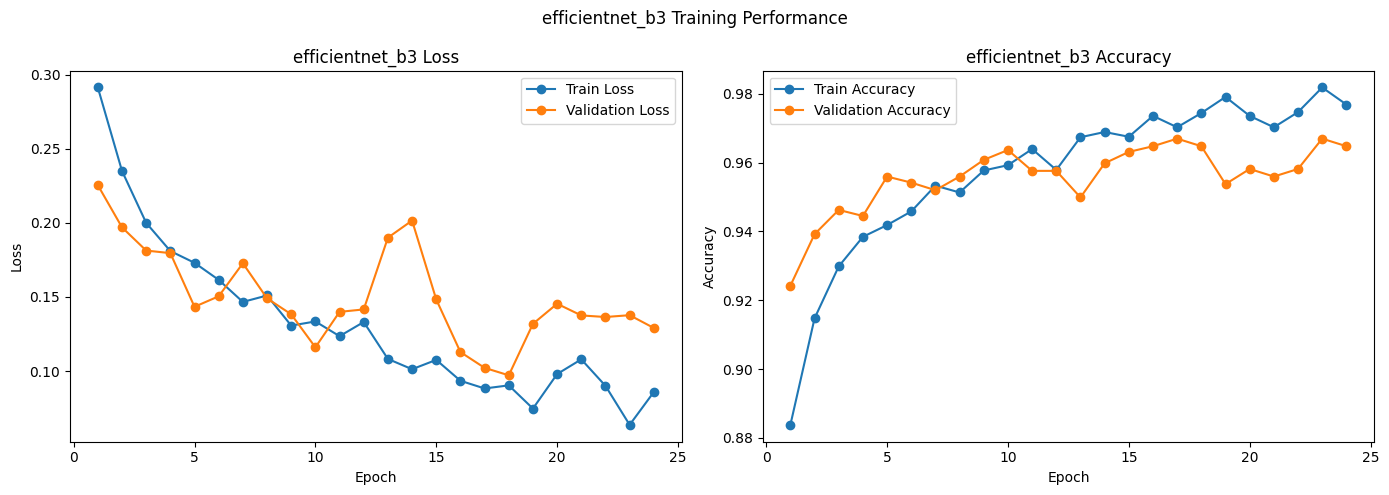

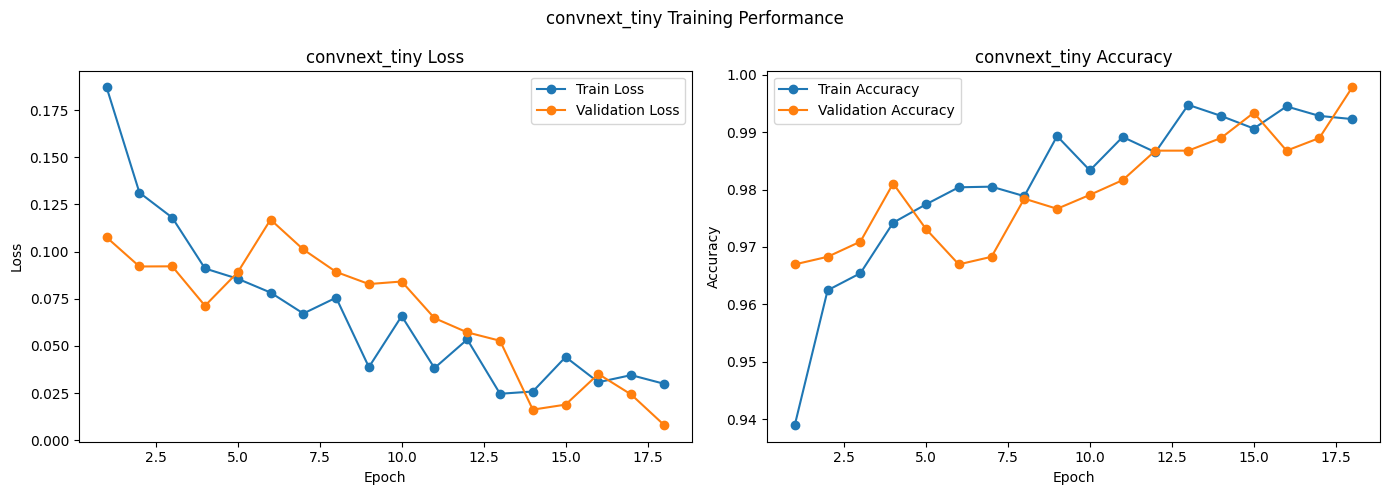

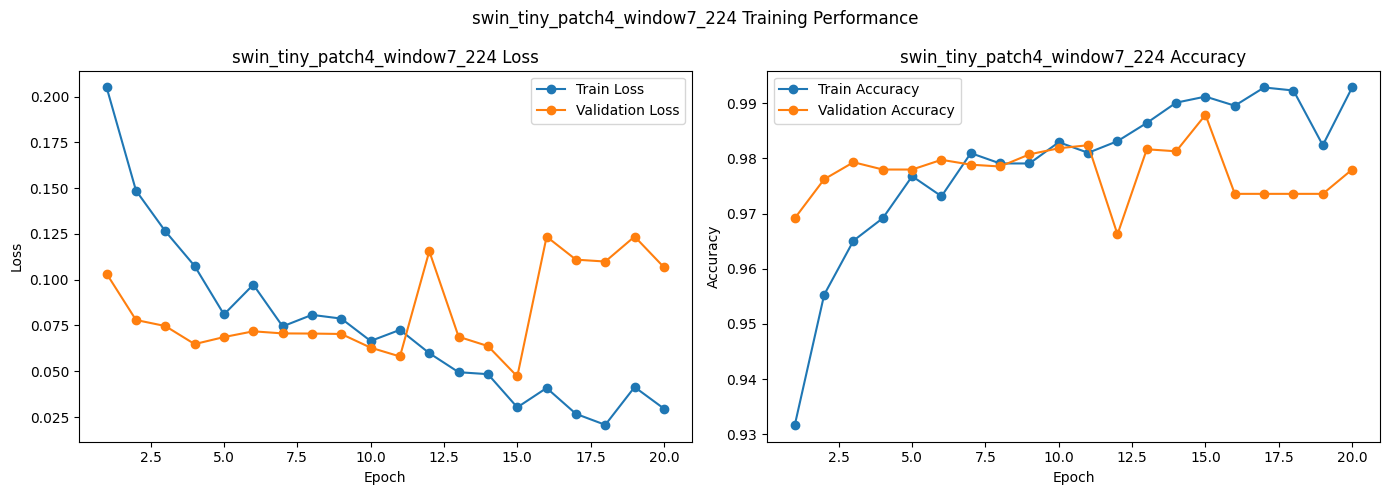

In [ ]:
for model_name in MODEL_NAMES:

    avg_history = average_history(
        history_all[model_name]
    )

    plot_history(
        avg_history,
        model_name
    )

In [ ]:
test_loader = create_loader(
    test_df,
    val_tf
)

In [ ]:
print("\n================================================")
print("BASE LEARNER EVALUATION")
print("================================================")

BASE_NAMES = [

    "EfficientNet-B3",

    "ConvNeXt-Tiny",

    "Swin-Tiny"
]


BASE LEARNER EVALUATION


In [ ]:
def predict_base_learner(
    models,
    weights,
    imgs,
    power
):

    fold_preds = []

    for model in models:

        model.eval()

        with torch.no_grad():

            pred = torch.sigmoid(
                model(imgs).squeeze(1)
            ).cpu().numpy()

            fold_preds.append(pred)

    fold_preds = np.array(fold_preds)

    fold_preds = fold_preds ** power

    return np.average(
        fold_preds,
        axis=0,
        weights=weights
    )

In [ ]:
def predict_base_model(
    models,
    weights,
    loader
):

    preds_all = []
    targets_all = []

    for imgs, labels in loader:

        imgs = imgs.to(DEVICE)

        fold_preds = []

        for model in models:

            model.eval()

            with torch.no_grad():

                probs = torch.sigmoid(
                    model(imgs).squeeze(1)
                ).cpu().numpy()

                fold_preds.append(probs)

        fold_preds = np.array(fold_preds)

        preds = np.average(
            fold_preds,
            axis=0,
            weights=weights
        )

        preds_all.extend(preds)
        targets_all.extend(labels.numpy())

    return (
        np.array(targets_all),
        np.array(preds_all)
    )


========== EfficientNet-B3 ==========
Accuracy : 0.9665
Precision: 0.9713
Recall   : 0.9610
F1 Score : 0.9661
AUC      : 0.9874

Confusion Matrix (Count):
[[278   8]
 [ 11 271]]


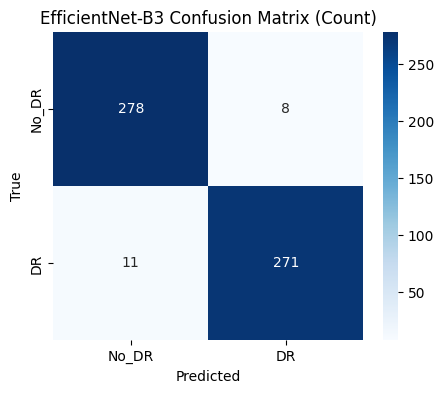


Confusion Matrix (%):
[[97.2  2.8]
 [ 3.9 96.1]]


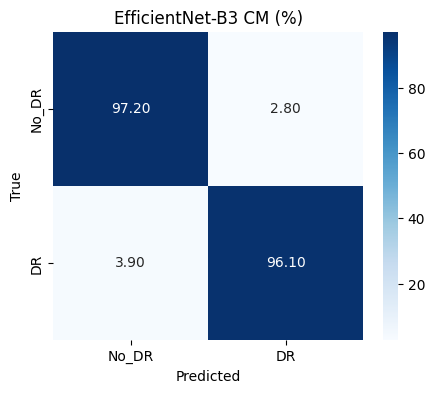


========== ConvNeXt-Tiny ==========
Accuracy : 0.9754
Precision: 0.9820
Recall   : 0.9681
F1 Score : 0.9750
AUC      : 0.9957

Confusion Matrix (Count):
[[281   5]
 [  9 273]]


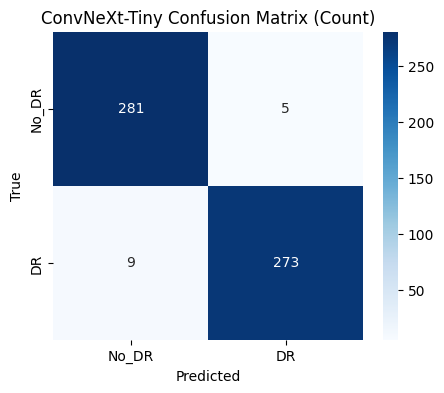


Confusion Matrix (%):
[[98.25  1.75]
 [ 3.19 96.81]]


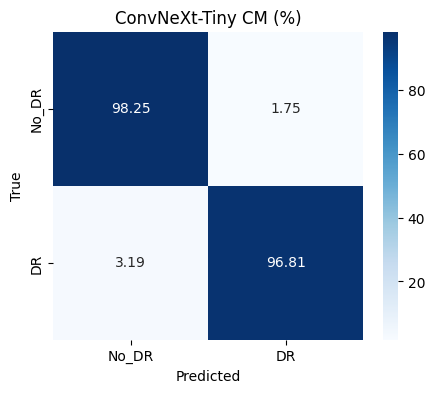


========== Swin-Tiny ==========
Accuracy : 0.9718
Precision: 0.9819
Recall   : 0.9610
F1 Score : 0.9713
AUC      : 0.9973

Confusion Matrix (Count):
[[281   5]
 [ 11 271]]


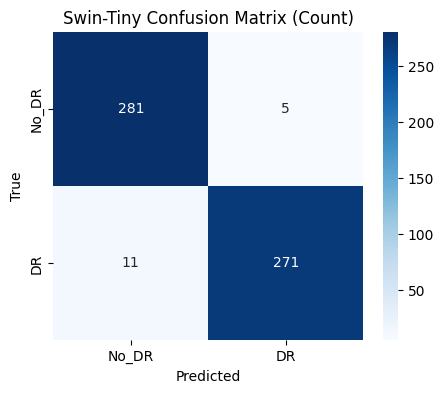


Confusion Matrix (%):
[[98.25  1.75]
 [ 3.9  96.1 ]]


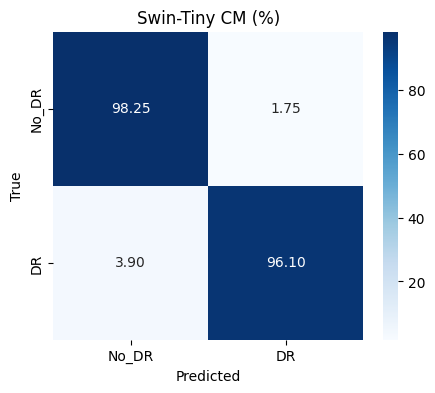


BASE MODEL WEIGHTS
EfficientNet-B3: 0.3313
ConvNeXt-Tiny: 0.3341
Swin-Tiny: 0.3346


In [ ]:
results_table = {}

base_aucs = []

for base_name, models, weights in zip(
    BASE_NAMES,
    all_models,
    all_weights
):

    print(f"\n========== {base_name} ==========")

    y_true, y_pred = predict_base_model(
        models,
        weights,
        test_loader
    )

    metrics = compute_metrics(
        y_true,
        y_pred
    )

    results_table[base_name] = [

        metrics["accuracy"],
        metrics["precision"],
        metrics["recall"],
        metrics["f1"],
        metrics["auc"]
    ]

    base_aucs.append(
        metrics["auc"]
    )

    print(f"Accuracy : {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall   : {metrics['recall']:.4f}")
    print(f"F1 Score : {metrics['f1']:.4f}")
    print(f"AUC      : {metrics['auc']:.4f}")

    print("\nConfusion Matrix (Count):")
    print(metrics["cm"])

    plot_cm(
        metrics["cm"],
        f"{base_name} Confusion Matrix (Count)",
        "d"
    )

    print("\nConfusion Matrix (%):")
    print(
        np.round(
            metrics["cm_percent"],
            2
        )
    )

    plot_cm(
        metrics["cm_percent"],
        f"{base_name} CM (%)",
        ".2f",
        f"performance/{base_name}_cm.png"
    )


In [ ]:
def ensemble_comparison(
    all_models,
    all_weights,
    loader,
    power_list=[2, 3, 4]
):

    comparison_results = {}

    for power in power_list:

        print(f"\n========== POWER VOTING {power} ==========")

        # ============================================
        # HITUNG BASE LEARNER SCORE
        # ============================================

        base_scores = []

        for models, weights in zip(
            all_models,
            all_weights
        ):

            preds = []
            targets = []

            for imgs, labels in loader:

                imgs = imgs.to(DEVICE)

                weighted_preds = predict_base_learner(
                    models,
                    weights,
                    imgs,
                    power
                )

                preds.extend(weighted_preds)
                targets.extend(labels.numpy())

            metrics = compute_metrics(
                np.array(targets),
                np.array(preds)
            )

            base_scores.append(
                metrics["auc"]
            )

        # ============================================
        # POWER WEIGHTS
        # ============================================

        base_scores = np.array(base_scores)

        power_weights = (
            base_scores ** power
        )

        power_weights /= power_weights.sum()

        print(
            "Base Scores:",
            np.round(base_scores, 4)
        )

        print(
            "Power Weights:",
            np.round(power_weights, 4)
        )

        # ============================================
        # FINAL ENSEMBLE
        # ============================================

        preds = []
        targets = []

        for imgs, labels in loader:

            imgs = imgs.to(DEVICE)

            model_preds = []

            for models, weights in zip(
                all_models,
                all_weights
            ):

                weighted_preds = predict_base_learner(
                    models,
                    weights,
                    imgs,
                    power
                )

                model_preds.append(
                    weighted_preds
                )

            model_preds = np.array(
                model_preds
            )

            final_preds = np.mean(
                model_preds,
                axis=0
            )

            preds.extend(final_preds)
            targets.extend(labels.numpy())

        preds = np.array(preds)
        targets = np.array(targets)

        metrics = compute_metrics(
            targets,
            preds
        )

        comparison_results[
            f"Power-{power}"
        ] = [

            metrics["accuracy"],
            metrics["precision"],
            metrics["recall"],
            metrics["f1"],
            metrics["auc"]
        ]

        print(
            f"Accuracy : {metrics['accuracy']:.4f}"
        )

        print(
            f"Precision: {metrics['precision']:.4f}"
        )

        print(
            f"Recall   : {metrics['recall']:.4f}"
        )

        print(
            f"F1 Score : {metrics['f1']:.4f}"
        )

        print(
            f"AUC      : {metrics['auc']:.4f}"
        )

    df_comparison = pd.DataFrame(

        comparison_results,

        index=[
            "Accuracy",
            "Precision",
            "Recall",
            "F1-Score",
            "AUC"
        ]
    ).round(4)

    print("\n================================================")
    print("POWER VOTING COMPARISON")
    print("================================================")

    display(df_comparison)

    return df_comparison

In [ ]:
def calibrate(y_true, y_pred):

    lr = LogisticRegression()

    lr.fit(
        y_pred.reshape(-1,1),
        y_true
    )

    calibrated = lr.predict_proba(
        y_pred.reshape(-1,1)
    )[:,1]

    return calibrated


In [ ]:
def plot_calibration_curve(
    y_true,
    y_pred,
    save_path
):

    prob_true, prob_pred = calibration_curve(
        y_true,
        y_pred,
        n_bins=6,
        strategy="quantile"
    )

    print("prob_pred =", prob_pred)
    print("prob_true =", prob_true)

    plt.figure(figsize=(7,7))

    plt.plot(
        prob_pred,
        prob_true,
        marker="o",
        linewidth=2.5,
        markersize=7,
        label="Calibrated Model"
    )

    plt.plot(
        [0,1],
        [0,1],
        "--",
        linewidth=2,
        label="Perfect Calibration"
    )

    plt.grid(alpha=0.3)

    plt.xlabel("Predicted Probability")
    plt.ylabel("True Probability")

    plt.title("Calibration Curve")

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

In [ ]:
def plot_roc_curve(
    y_true,
    y_pred,
    save_path
):

    fpr, tpr, _ = roc_curve(
        y_true,
        y_pred
    )

    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,6))

    plt.plot(
        fpr,
        tpr,
        label=f"AUC = {roc_auc:.4f}"
    )

    plt.plot(
        [0,1],
        [0,1],
        "--"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title("ROC Curve")

    plt.legend()

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

In [ ]:
def ensemble(
    all_models,
    all_weights,
    loader,
    power=2
):

    preds_all = []
    targets_all = []


    for imgs, labels in loader:

        imgs = imgs.to(DEVICE)

        model_preds = []

        for models, weights in zip(
            all_models,
            all_weights
        ):

            fold_preds = []

            for model in models:

                model.eval()

                with torch.no_grad():

                    probs = torch.sigmoid(
                        model(imgs).squeeze(1)
                    ).cpu().numpy()

                    fold_preds.append(probs)

            fold_preds = np.array(fold_preds)

            # ====================================
            # POWER VOTING (VERSI LAMA)
            # ====================================

            fold_preds = fold_preds ** power

            weighted_preds = np.average(
                fold_preds,
                axis=0,
                weights=weights
            )

            model_preds.append(
                weighted_preds
            )

        model_preds = np.array(
            model_preds
        )

        # ====================================
        # AVERAGE ANTAR BASE LEARNER
        # ====================================

        final_preds = np.mean(
            model_preds,
            axis=0
        )

        preds_all.extend(
            final_preds
        )

        targets_all.extend(
            labels.numpy()
        )

    return (
        np.array(targets_all),
        np.array(preds_all)
    )

In [ ]:
def evaluate_power_voting(
    power_values=[2,3,4]
):

    comparison_results = {}

    for power_k in power_values:

        y_true_cmp, y_pred_cmp = ensemble(
            all_models,
            all_weights,
            test_loader,
            power=power_k
        )

        metrics_cmp = compute_metrics(
            y_true_cmp,
            y_pred_cmp
        )

        comparison_results[f"Power-{power_k}"] = [

            metrics_cmp["accuracy"],
            metrics_cmp["precision"],
            metrics_cmp["recall"],
            metrics_cmp["f1"],
            metrics_cmp["auc"]
        ]

    return pd.DataFrame(

        comparison_results,

        index=[
            "Accuracy",
            "Precision",
            "Recall",
            "F1-Score",
            "AUC"
        ]
    ).round(4)

,Power-2,Power-3,Power-4
Accuracy,0.9683,0.9613,0.9577
Precision,0.9818,0.9815,0.9850
Recall,0.9539,0.9397,0.9291
F1-Score,0.9676,0.9601,0.9562
AUC,0.9948,0.9948,0.9948


prob_pred = [0.04981948 0.04995405 0.05827501 0.87068696 0.97402966 0.97648008]
prob_true = [0.         0.01052632 0.04255319 0.92631579 1.         1.        ]


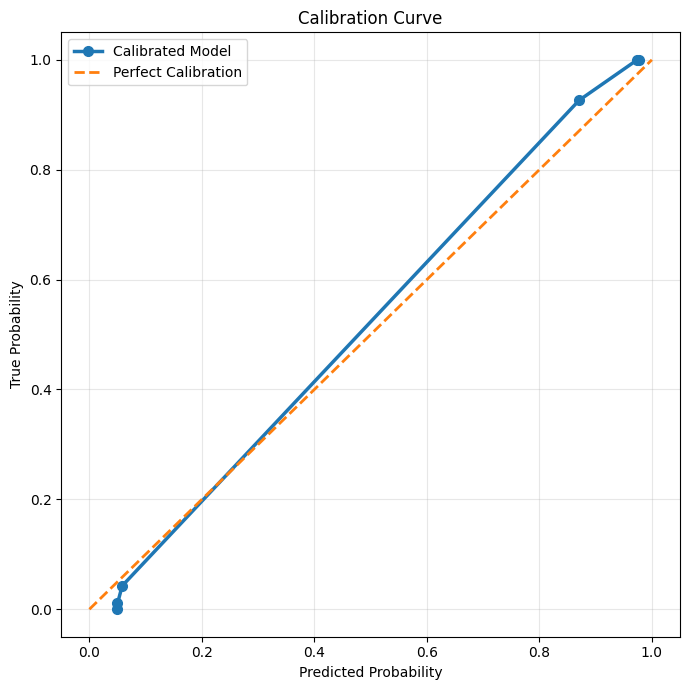

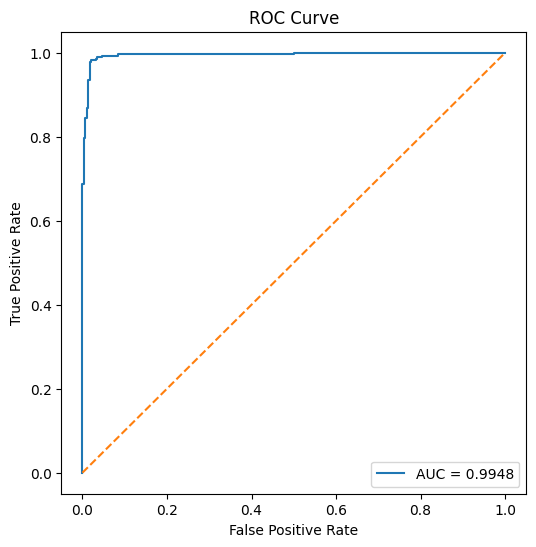

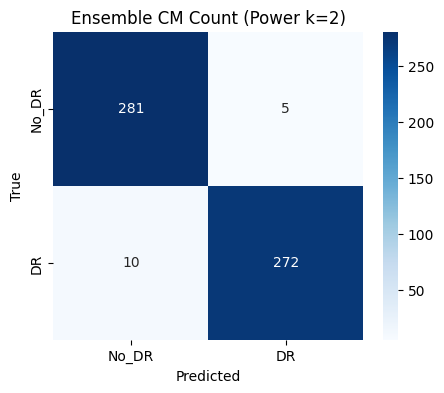

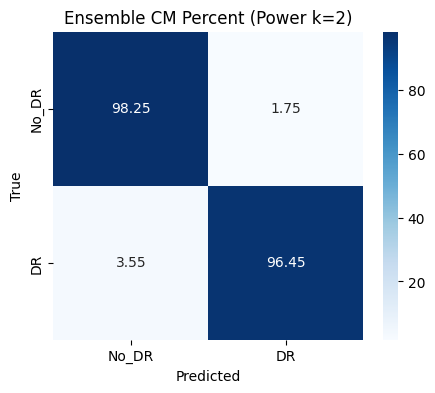

In [ ]:
# ==========================================
# POWER COMPARISON
# ==========================================

df_comparison = evaluate_power_voting()

display(df_comparison)

# ==========================================
# FINAL ENSEMBLE
# ==========================================

POWER_K = 2

y_true, y_pred = ensemble(
    all_models,
    all_weights,
    test_loader,
    power=POWER_K
)

# ==========================================
# PLATT SCALING
# ==========================================

calibrator = LogisticRegression()

calibrator.fit(
    y_pred.reshape(-1, 1),
    y_true
)

y_pred_cal = calibrator.predict_proba(
    y_pred.reshape(-1, 1)
)[:, 1]

# ==========================================
# CALIBRATION
# ==========================================

plot_calibration_curve(
    y_true,
    y_pred_cal,
    "performance/calibration_curve.png"
)

joblib.dump(
    calibrator,
    "calibrator.pkl"
)

# ==========================================
# METRICS
# ==========================================

ensemble_metrics = compute_metrics(
    y_true,
    y_pred_cal
)

# ==========================================
# ROC
# ==========================================

plot_roc_curve(
    y_true,
    y_pred_cal,
    "performance/roc_curve.png"
)

# ==========================================
# CONFUSION MATRIX
# ==========================================

plot_cm(
    ensemble_metrics["cm"],
    f"Ensemble CM Count (Power k={POWER_K})",
    "d",
    "performance/ensemble_cm_count.png"
)

plot_cm(
    ensemble_metrics["cm_percent"],
    f"Ensemble CM Percent (Power k={POWER_K})",
    ".2f",
    "performance/ensemble_cm_percent.png"
)

In [ ]:
print("Base AUCs:")
print(base_aucs)

print("\nBASE_MODEL_WEIGHTS:")
print(BASE_MODEL_WEIGHTS)

Base AUCs:
[np.float64(0.9874274661508703), np.float64(0.9957223627436393), np.float64(0.9972598323662153)]

BASE_MODEL_WEIGHTS:
[0.33130595 0.33408909 0.33460495]


In [ ]:
for p in [2,3,4]:

    w = np.array(base_aucs) ** p
    w /= w.sum()

    print(f"Power {p}:")
    print(np.round(w, 6))

Power 2:
[0.329285 0.33484  0.335875]
Power 3:
[0.32727  0.335587 0.337144]
Power 4:
[0.325261 0.336329 0.338411]


In [ ]:
ensemble_config = {

    "model_names": [

        "efficientnet_b3",

        "convnext_tiny",

        "swin_tiny_patch4_window7_224"
    ],

    "model_paths": {

        "efficientnet_b3": [

            "models/efficientnet_b3_fold_1.pth",
            "models/efficientnet_b3_fold_2.pth",
            "models/efficientnet_b3_fold_3.pth",
            "models/efficientnet_b3_fold_4.pth",
            "models/efficientnet_b3_fold_5.pth"
        ],

        "convnext_tiny": [

            "models/convnext_tiny_fold_1.pth",
            "models/convnext_tiny_fold_2.pth",
            "models/convnext_tiny_fold_3.pth",
            "models/convnext_tiny_fold_4.pth",
            "models/convnext_tiny_fold_5.pth"
        ],

        "swin_tiny_patch4_window7_224": [

            "models/swin_tiny_patch4_window7_224_fold_1.pth",
            "models/swin_tiny_patch4_window7_224_fold_2.pth",
            "models/swin_tiny_patch4_window7_224_fold_3.pth",
            "models/swin_tiny_patch4_window7_224_fold_4.pth",
            "models/swin_tiny_patch4_window7_224_fold_5.pth"
        ]
    },

    "weights": all_weights,

    "base_model_weights":

        BASE_MODEL_WEIGHTS.tolist(),

    "power_k": POWER_K,

    "class_names": [

        "No_DR",

        "DR"
    ]
}

torch.save(
    ensemble_config, "ensemble_config.pth"
)
print("ensemble_config.pth saved")

ensemble_config.pth saved


In [ ]:
# =========================================================
# GENERATE requirements.txt
# =========================================================

import torch
import torchvision
import timm
import sklearn
import numpy
import pandas
import PIL
import matplotlib
import seaborn
import joblib

requirements = [
    f"torch=={torch.__version__}",
    f"torchvision=={torchvision.__version__}",
    f"timm=={timm.__version__}",
    f"scikit-learn=={sklearn.__version__}",
    f"numpy=={numpy.__version__}",
    f"pandas=={pandas.__version__}",
    f"Pillow=={PIL.__version__}",
    f"matplotlib=={matplotlib.__version__}",
    f"seaborn=={seaborn.__version__}",
    f"joblib=={joblib.__version__}",
    "streamlit"
]

with open("requirements.txt", "w") as f:
    f.write("\n".join(requirements))

print("requirements.txt created successfully")

requirements.txt created successfully


In [ ]:
with open("requirements.txt", "r") as f:

    print(f.read())

torch==2.11.0+cu128
torchvision==0.26.0+cu128
timm==1.0.27
scikit-learn==1.6.1
numpy==2.0.2
pandas==2.2.2
Pillow==11.3.0
matplotlib==3.10.0
seaborn==0.13.2
joblib==1.5.3
streamlit


In [ ]:
from google.colab import files

files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
test_df.to_csv(
    "test_dataset.csv",
    index=False
)

4.1 Implementasi Persiapan Dataset
4.1.1 Import Library
4.1.2 Pemuatan dan Ekstraksi Dataset
4.1.3 Pembentukan DataFrame Dataset
4.1.4 Pembagian Dataset Training dan Testing
4.2 Implementasi Preprocessing dan Augmentasi Data
4.2.1 Crop Retina pada Citra Fundus
4.2.2 Resize dan Normalisasi Citra
4.2.3 Augmentasi Data
4.2.4 Transformasi Dataset
4.3 Implementasi Arsitektur Model
4.3.1 Implementasi Model EfficientNet-B3
4.3.2 Implementasi Model ConvNeXt-Tiny
4.3.3 Implementasi Model Swin Transformer Tiny
4.3.4 Modifikasi Fully Connected Layer
4.4 Implementasi Pelatihan Model
4.4.1 Inisialisasi Dataset dan DataLoader
4.4.2 Implementasi Stratified K-Fold Cross Validation
4.4.3 Proses Training Model
4.4.4 Proses Validasi Model
4.4.5 Penyimpanan Model Terbaik
4.5 Implementasi Evaluasi Model
4.5.1 Perhitungan Accuracy, Precision, Recall, dan F1-Score
4.5.2 Confusion Matrix
4.5.3 ROC Curve dan AUC Score
4.5.4 Visualisasi Hasil Pelatihan dan Validasi
4.6 Implementasi Ensemble Learning
4.6.1 Evaluasi Base Learner
4.6.2 Implementasi Weighted Ensemble
4.6.3 Kalibrasi Probabilitas Menggunakan Logistic Regression
4.6.4 Evaluasi Model Ensemble
4.7 Analisis dan Perbandingan Performa Model
4.7.1 Analisis Performa EfficientNet-B3
4.7.2 Analisis Performa ConvNeXt-Tiny
4.7.3 Analisis Performa Swin Transformer Tiny
4.7.4 Perbandingan Performa Base Learner dan Ensemble
4.8 Implementasi Model pada Streamlit

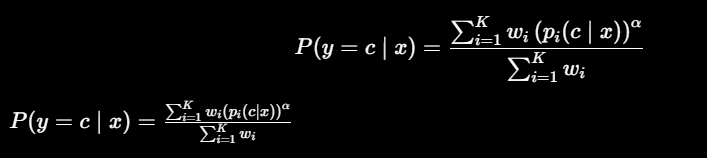